In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.utils import make_grid

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

epochs = 1000
lr = 2e-4
latent_dim = 100
b1, b2 = 0.5, 0.999
batch_size = 32

data_path = "data"
img_size = 64
img_shape = (3, img_size, img_size)

device

device(type='mps')

## Create dataset

In [18]:
from data_handling import DataHandler

data_handler = DataHandler(data_path, img_size, batch_size)

loader = data_handler.get_loader()

Loading images:   0%|          | 0/141 [00:00<?, ?it/s]

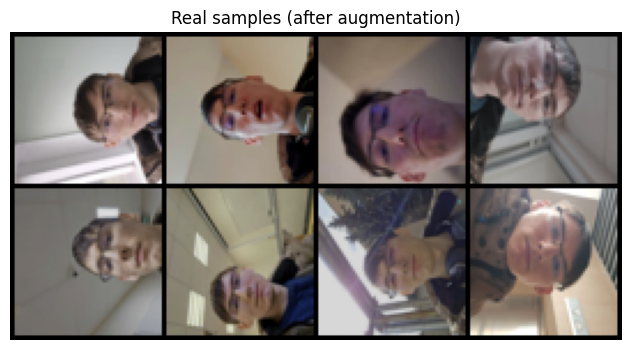

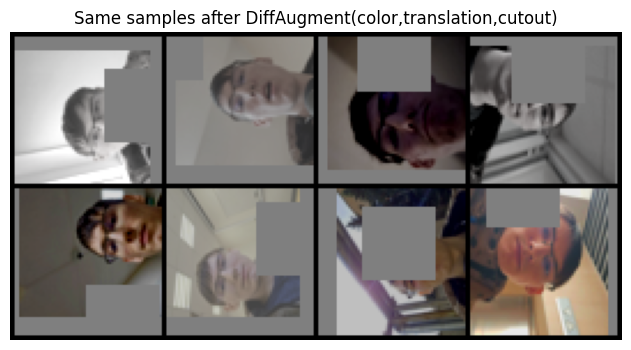

In [ ]:
# powered by cursor

def denormalize(images: torch.Tensor) -> torch.Tensor:
    """Map a tensor produced by Normalize(0.5, 0.5) / Tanh back to [0, 1]."""
    return (images.detach().cpu() + 1) / 2


def show_grid(images: torch.Tensor, nrow: int = 4, title: str | None = None):
    grid = make_grid(denormalize(images), nrow=nrow, padding=2).clamp(0, 1)
    plt.figure(figsize=(nrow * 2, (images.size(0) // nrow) * 2))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()


batch = next(iter(loader))
show_grid(batch[:8], nrow=4, title="Real samples (after augmentation)")

from diff_augment import diff_augment
augmented = diff_augment(batch[:8].to(device), "color,translation,cutout")
show_grid(augmented, nrow=4, title="Same samples after DiffAugment(color,translation,cutout)")

## Train model

In [ ]:
from network import Generator, Discriminator

generator = Generator(img_shape, latent_dim=latent_dim).to(device)
discriminator = Discriminator(img_shape).to(device)

optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

adversarial_loss = torch.nn.BCEWithLogitsLoss()

Generator params:       3.58M
Discriminator params:   2.77M


In [ ]:
from trainer import GANTrainer
from IPython.display import clear_output

def on_epoch_end(trainer: GANTrainer, epoch: int) -> None:
    if (epoch + 1) % 10 == 0 or epoch == 0:
        samples = trainer.predict_fixed()
        clear_output(wait=True)
        show_grid(samples, nrow=4, title=f"Fixed-noise samples after epoch {epoch + 1}")

trainer = GANTrainer(
    generator,
    discriminator,
    optimizer_G,
    optimizer_D,
    adversarial_loss,
    device,
    epochs,
    latent_dim=latent_dim,
    real_label_smoothing=0.9,
    on_epoch_end=on_epoch_end,
    diff_augment_policy="color,translation,cutout",
)

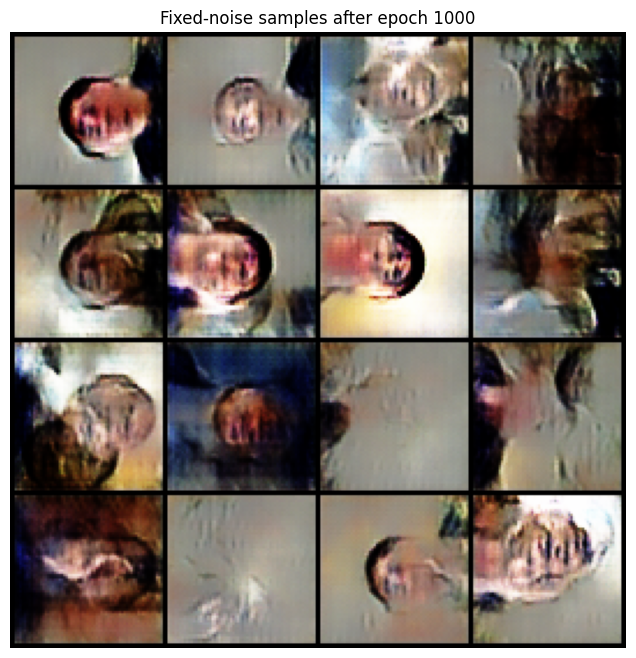

In [22]:
trainer.fit(loader)

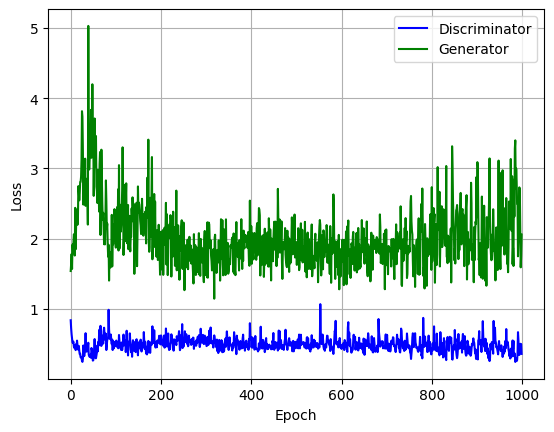

In [23]:
plt.plot(trainer.discriminator_loss_history, color='blue', label='Discriminator')
plt.plot(trainer.generator_loss_history, color='green', label='Generator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

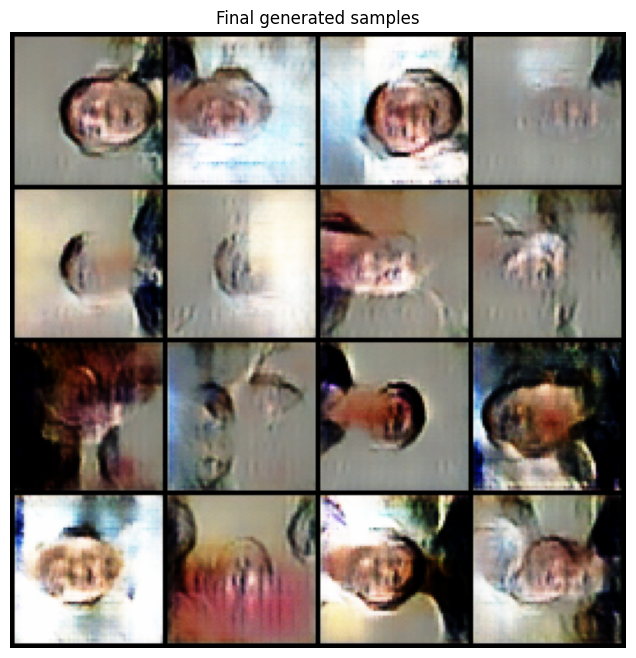

In [24]:
samples = trainer.predict(num_samples=16)
show_grid(samples, nrow=4, title="Final generated samples")